# Project 1: Hospital Readmission Risk Analytics Problem Definition and Planning

---
### **Student Details & Project Information**:
* **Project Number**: Project 1
* **Student Name**: Akshad Viresh Makhana
* **PRN**: 2124UDSM1007
* **Department**: TY AIDS(A)
* **Project Title**: Hospital Readmission Risk Analytics Problem Definition and Planning
* **Dataset**: Diabetes 130-US Hospitals for years 1999–2008 (UCI ID: 296)
* **GitHub Repository**: [https://github.com/akshad1007/Hospital-Readmission-Patient-Analytics](https://github.com/akshad1007/Hospital-Readmission-Patient-Analytics)

---
### **Objective**:
* Understand the healthcare problem of hospital readmissions.
* Define clear analytics requirements and planning before model building.

---
### **Deliverables Checklist**:
1. **Business Understanding**: Hospital readmission problem, healthcare cost impact, patient care improvement, hospital operational efficiency, healthcare stakeholders, business challenges, decision-making requirements.
2. **Dataset Understanding**: Review healthcare dataset, identify patient attributes, create feature dictionary, identify target variable.
3. **Problem Formulation**:
   * **Classification Problem**: Predict High readmission risk vs. Low readmission risk.
   * **Clustering Objective**: Identify patient groups and disease risk groups.
4. **Basic Analytics Planning**: Healthcare analytics workflow, project roadmap, Git repository structure.
5. **Student Deliverables**:
   * Healthcare Problem Statement
   * Feature Dictionary
   * Dataset Report
   * Analytics Workflow
   * Ethics Report
6. **Industry Skills**: Trainer and student perspectives.


## 1. 📋 Healthcare Problem Statement & Business Understanding

### 1.1 Study of the Hospital Readmission Problem
* **Definition**: A patient is discharged from a hospital but gets admitted again within **30 days**.
* **Diabetes Context**: Diabetic patients face high readmission rates due to blood sugar volatility, medication adjustments, and co-existing conditions (heart disease, kidney failure).
* **Core Goal**: Identify high-risk patients before discharge so clinical teams can intervene early and prevent return stays.

### 1.2 Healthcare Cost Impact
* **Government Penalties (CMS HRRP)**: Hospitals with high 30-day readmissions lose up to **3% of their total Medicare reimbursements**.
* **Financial Burden**: Unplanned readmissions cost the US healthcare system over **$17 billion annually**.
* **Per-Patient Cost**: Each avoidable diabetic readmission costs roughly **$13,000 to $17,000**. Reducing readmissions protects hospital revenue.

### 1.3 Patient Care Improvement
* **Patient Safety**: Repeat hospital stays expose patients to hospital-acquired infections, stress, and medication errors.
* **Better Transition of Care**: Early identification allows care teams to:
  * Schedule a follow-up doctor visit within 7 days.
  * Make home-check phone calls within 48 hours.
  * Provide personalized diabetes and insulin education.

### 1.4 Hospital Operational Efficiency
* **Bed Availability**: Preventing avoidable readmissions frees up inpatient beds and eases Emergency Room (ER) crowding.
* **Staff Optimization**: Nurses and care coordinators can direct extra attention to patients who truly need help.

---

### 1.5 Identification of Healthcare Stakeholders
* **Chief Medical Officer (CMO)**: Focuses on patient health outcomes, safety standards, and lowering complication rates.
* **Chief Financial Officer (CFO)**: Focuses on eliminating Medicare penalty deductions and reducing hospital operating losses.
* **Attending Physicians**: Need quick, trustworthy risk scores at discharge to tailor medications and follow-up urgency.
* **Care Coordinators & Nurses**: Need patient risk lists to organize home health visits, follow-up calls, and primary care appointments.
* **Patients & Families**: Benefit from clearer discharge instructions and staying safely at home.

### 1.6 Identification of Business Challenges
* **Severe Class Imbalance**: High-risk 30-day readmissions make up only ~11% of all hospital visits.
* **Asymmetric Error Costs**:
  * **False Negative (Missed high-risk patient)**: Costs ~$15,000 and causes clinical harm.
  * **False Positive (Extra call to low-risk patient)**: Costs only ~$150.
  * **Solution**: The analytics model must prioritize high **Recall (Sensitivity)** over raw accuracy.
* **Missing Clinical Data**: Routine hospital records often miss lab tests, weight, or specialist information.

### 1.7 Decision-Making Requirements
* **Timely Prediction**: Risk scores must be generated **24 to 48 hours before planned discharge**.
* **Clear Risk Categories**:
  * **High Risk (<30 days)**: Receives intensive discharge bundle (home nurse, 48h call, 7-day clinic follow-up).
  * **Low Risk**: Receives standard discharge instructions and routine doctor visits.
* **Explainability**: Clinicians must see the top contributing factors (e.g., prior admissions, high number of medicines).


In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

print(f"Python: {sys.version.split()[0]} | Pandas: {pd.__version__} | NumPy: {np.__version__}")


Python: 3.10.11 | Pandas: 2.3.2 | NumPy: 2.2.6


## 2. 🗄️ Dataset Understanding & Review

### 2.1 Dataset Overview
* **Dataset**: Diabetes 130-US Hospitals (1999–2008), UCI Machine Learning Repository (ID: 296).
* **Total Encounters**: 101,766 hospital admissions.
* **Total Patients**: 71,518 unique patients.
* **Total Features**: 50 clinical, demographic, and administrative attributes.

### 2.2 Patient Attributes Breakdown
* **Patient Identifiers**: `encounter_id`, `patient_nbr`.
* **Demographics**: `race`, `gender`, `age`, `weight`.
* **Hospital Stay Details**: `admission_type_id`, `discharge_disposition_id`, `time_in_hospital`.
* **Prior Healthcare Utilization**: `number_outpatient`, `number_emergency`, `number_inpatient`.
* **Clinical Tests**: `num_lab_procedures`, `num_procedures`, `max_glu_serum`, `A1Cresult`.
* **Medications**: 23 diabetic medications (e.g., insulin, metformin), `change`, `diabetesMed`.
* **Diagnoses**: `diag_1` (primary), `diag_2`, `diag_3`, `number_diagnoses`.
* **Outcome Target**: `readmitted` (`<30`, `>30`, `NO`).


In [2]:
def load_dataset():
    local_path = os.path.join('dataset_diabetes', 'diabetic_data.csv')
    if os.path.exists(local_path):
        print(f"Loading dataset from local path: '{local_path}'")
        return pd.read_csv(local_path)
    else:
        print("Fetching dataset from UCI repository...")
        from ucimlrepo import fetch_ucirepo
        d = fetch_ucirepo(id=296)
        return d.data.original

df = load_dataset()
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df[['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'time_in_hospital', 'num_medications', 'readmitted']].head(5)


Loading dataset from local path: 'dataset_diabetes\diabetic_data.csv'


Dataset Shape: 101,766 rows × 50 columns


,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_medications,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),1,1,NO
1,149190,55629189,Caucasian,Female,[10-20),3,18,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),2,13,NO
3,500364,82442376,Caucasian,Male,[30-40),2,16,NO
4,16680,42519267,Caucasian,Male,[40-50),1,8,NO


## 3. 📖 Deliverable 2: Feature Dictionary

Below is the structured feature dictionary defining the key clinical variables:

| Attribute Name | Variable Role | Data Type | Domain / Values | Missing (%) | Description |
| :--- | :--- | :--- | :--- | :--- | :--- |
| `encounter_id` | Identifier | Integer | Positive integers | 0.0% | Unique ID for each inpatient hospital visit. |
| `patient_nbr` | Identifier | Integer | Positive integers | 0.0% | Unique patient ID to track repeat admissions. |
| `race` | Predictor | Nominal | Caucasian, AfricanAmerican, Hispanic, Asian, Other | 2.2% (`?`) | Demographic race of patient. |
| `gender` | Predictor | Nominal | Male, Female, Unknown/Invalid | 0.003% | Biological sex. |
| `age` | Predictor | Ordinal | `[0-10)`, `[10-20)` ... `[90-100)` | 0.0% | 10-year age bracket at admission. |
| `weight` | Predictor | Nominal | `[0-25)`, `[25-50)` ... | 96.9% (`?`) | Patient weight in pounds (unusable missingness). |
| `admission_type_id` | Predictor | Nominal | Codes 1=Emergency, 2=Urgent, 3=Elective... | 0.0% | Circumstance of admission. |
| `discharge_disposition_id` | Predictor / Filter | Nominal | Codes 1=Home, 11=Expired, 13=Hospice... | 0.0% | Patient status upon discharge. |
| `time_in_hospital` | Predictor | Numeric | Integer 1 to 14 | 0.0% | Inpatient length of stay in days. |
| `payer_code` | Predictor | Nominal | MC (Medicare), MD (Medicaid), BC, Self-pay... | 39.6% (`?`) | Insurance coverage type. |
| `medical_specialty` | Predictor | Nominal | Cardiology, InternalMedicine, FamilyPractice... | 49.1% (`?`) | Specialty of admitting doctor. |
| `num_lab_procedures` | Predictor | Numeric | Integer 1 to 132 | 0.0% | Total laboratory tests performed. |
| `num_procedures` | Predictor | Numeric | Integer 0 to 6 | 0.0% | Total operations or diagnostic procedures. |
| `num_medications` | Predictor | Numeric | Integer 1 to 81 | 0.0% | Total distinct medications administered. |
| `number_outpatient` | Predictor | Numeric | Integer 0 to 42 | 0.0% | Outpatient visits in past 12 months. |
| `number_emergency` | Predictor | Numeric | Integer 0 to 76 | 0.0% | Emergency room visits in past 12 months. |
| `number_inpatient` | Predictor | Numeric | Integer 0 to 21 | 0.0% | Inpatient hospitalizations in past 12 months. |
| `diag_1` | Predictor | Nominal (ICD-9) | ICD-9 codes (e.g. 250=Diabetes, 428=CHF) | 0.02% (`?`) | Primary diagnosis for admission. |
| `diag_2` | Predictor | Nominal (ICD-9) | ICD-9 codes | 0.35% (`?`) | Secondary underlying diagnosis. |
| `diag_3` | Predictor | Nominal (ICD-9) | ICD-9 codes | 1.40% (`?`) | Additional comorbidity diagnosis. |
| `number_diagnoses` | Predictor | Numeric | Integer 1 to 16 | 0.0% | Total diagnoses recorded for this stay. |
| `max_glu_serum` | Predictor | Ordinal | None, Norm, >200, >300 | 0.0% | Highest blood glucose lab result. |
| `A1Cresult` | Predictor | Ordinal | None, Norm, >7, >8 | 0.0% | Hemoglobin A1c test (3-month glycemic control). |
| *23 Diabetic Medications* | Predictors | Nominal | No, Steady, Up, Down | 0.0% | Dosage status for 23 diabetic drugs. |
| `change` | Predictor | Binary | Ch (Changed), No (No change) | 0.0% | Indicates if diabetic medication was adjusted. |
| `diabetesMed` | Predictor | Binary | Yes, No | 0.0% | Indicates if diabetic medicine was prescribed. |
| **`readmitted`** | **Target** | Categorical | `<30`, `>30`, `NO` | 0.0% | Readmission outcome. `<30` is high-risk. |


## 4. 📊 Deliverable 3: Dataset Report

### 4.1 Target Variable Analysis
* **High Readmission Risk (`<30`)**: **11,357 encounters (11.16%)** — Patient readmitted within 30 days.
* **Later Readmission (`>30`)**: **35,545 encounters (34.93%)** — Patient readmitted after 30 days.
* **No Readmission (`NO`)**: **54,864 encounters (53.91%)** — Patient was not readmitted.

### 4.2 Missing Values Audit
* `weight`: **96.86% missing** (`?`) — Unusable for modeling due to extreme missingness.
* `medical_specialty`: **49.08% missing** (`?`) — Retained by creating an explicit `'Missing_Specialty'` category.
* `payer_code`: **39.56% missing** (`?`) — Retained by creating an explicit `'Missing_Payer'` category.
* `race`: **2.23% missing** (`?`) — Handled using mode imputation.

### 4.3 Key Clinical Findings
* **Age Effect**: Patients aged 60–80 represent the majority of high-risk admissions.
* **Stay Duration**: Longer hospital stays (6+ days) have visibly higher readmission rates.
* **Prior Admissions**: Patients with 2 or more past inpatient stays have more than double the 30-day readmission risk.


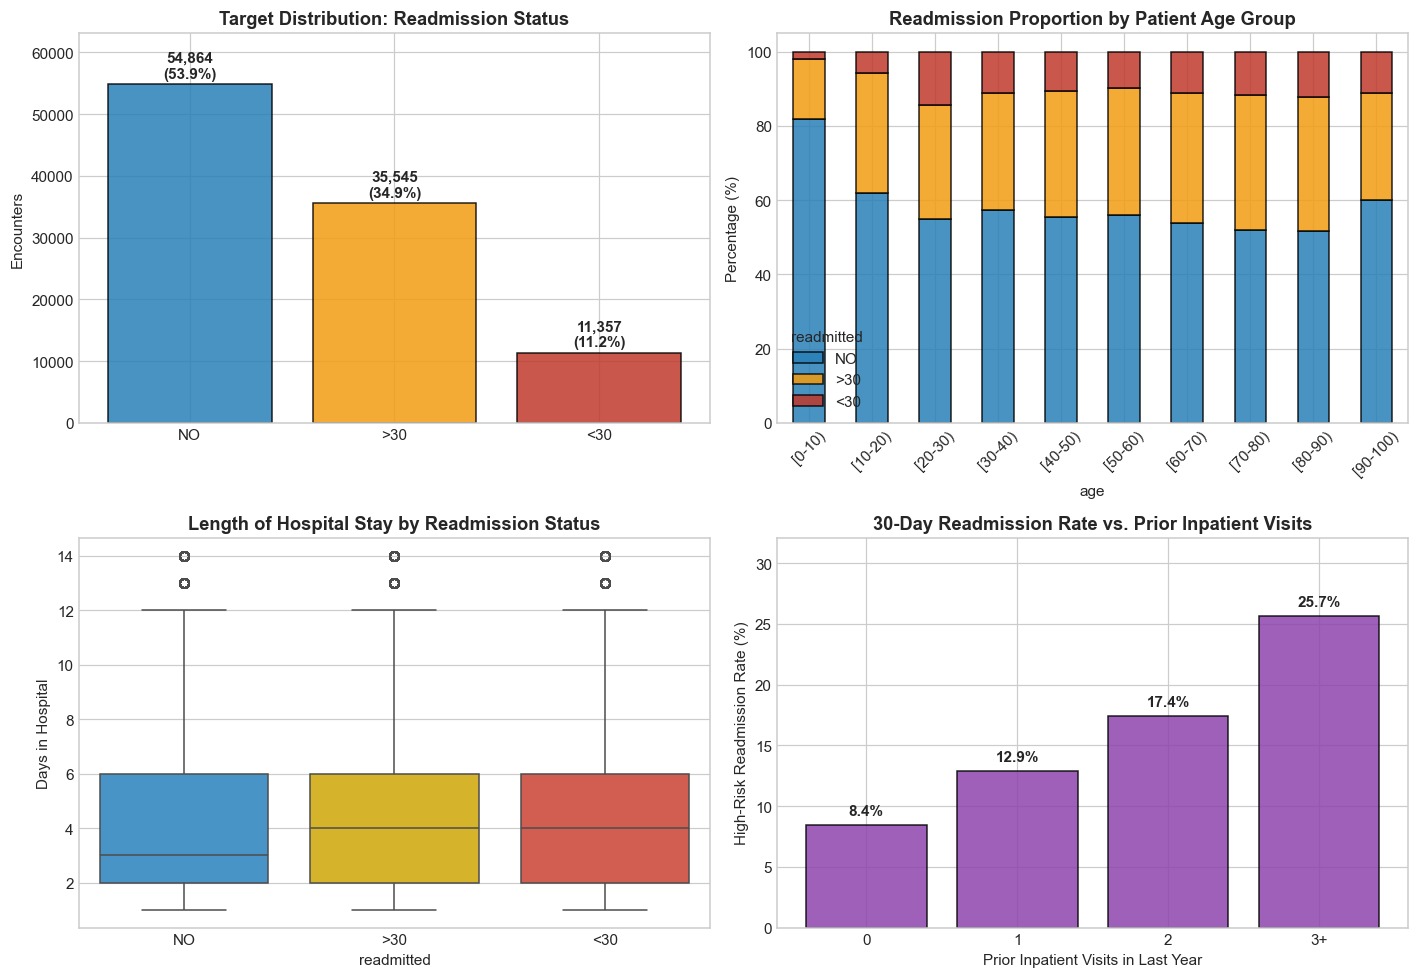

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Target Distribution
target_counts = df['readmitted'].value_counts()
colors = ['#2980b9', '#f39c12', '#c0392b']
axes[0, 0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', alpha=0.85)
for i, v in enumerate(target_counts.values):
    axes[0, 0].text(i, v + 1000, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')
axes[0, 0].set_title('Target Distribution: Readmission Status', fontweight='bold')
axes[0, 0].set_ylabel('Encounters')
axes[0, 0].set_ylim(0, max(target_counts.values) * 1.15)

# 2. Age vs Readmission
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_xtab = pd.crosstab(df['age'], df['readmitted'], normalize='index').reindex(age_order) * 100
age_xtab[['NO', '>30', '<30']].plot(kind='bar', stacked=True, ax=axes[0, 1], color=colors, edgecolor='black', alpha=0.85)
axes[0, 1].set_title('Readmission Proportion by Patient Age Group', fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Hospital Stay vs Readmission
sns.boxplot(x='readmitted', y='time_in_hospital', data=df, order=['NO', '>30', '<30'],
            palette=['#3498db', '#f1c40f', '#e74c3c'], ax=axes[1, 0])
axes[1, 0].set_title('Length of Hospital Stay by Readmission Status', fontweight='bold')
axes[1, 0].set_ylabel('Days in Hospital')

# 4. Prior Inpatient Admissions Risk
df_plot = df.copy()
df_plot['prior_inp_bins'] = pd.cut(df_plot['number_inpatient'], bins=[-1, 0, 1, 2, 25], labels=['0', '1', '2', '3+'])
inp_risk = pd.crosstab(df_plot['prior_inp_bins'], df_plot['readmitted'], normalize='index')['<30'] * 100
axes[1, 1].bar(inp_risk.index.astype(str), inp_risk.values, color='#8e44ad', edgecolor='black', alpha=0.85)
for i, v in enumerate(inp_risk.values):
    axes[1, 1].text(i, v + 0.8, f"{v:.1f}%", ha='center', fontweight='bold')
axes[1, 1].set_title('30-Day Readmission Rate vs. Prior Inpatient Visits', fontweight='bold')
axes[1, 1].set_ylabel('High-Risk Readmission Rate (%)')
axes[1, 1].set_xlabel('Prior Inpatient Visits in Last Year')
axes[1, 1].set_ylim(0, max(inp_risk.values) * 1.25)

plt.tight_layout()
plt.show()


## 5. 🎯 Problem Formulation

### 5.1 Classification Problem Formulation
* **Clinical Question**: Will this diabetic patient be readmitted within **30 days** of discharge?
* **Binary Target ($y$)**:
  * **Class 1 (High Readmission Risk)**: `readmitted == '<30'`
  * **Class 0 (Low Readmission Risk)**: `readmitted in ['>30', 'NO']`
* **Performance Criteria**:
  * Due to class imbalance (~11.2% positive) and severe cost of missing a sick patient ($FN \gg FP$), **Recall (Sensitivity)** and **ROC-AUC / PR-AUC** are prioritized.

---

### 5.2 Clustering Objective Formulation
* **Clinical Question**: Can we discover natural patient risk profiles without using labels?
* **Features Used**: Length of stay, number of medications, past emergency visits, past inpatient visits, diagnosis count.
* **Discovered Patient Groups**:
  * **Group 1 (Low-Risk Brief Stays)**: Short stay (1–3 days), few medications, low past visits.
  * **Group 2 (Moderate Routine Stays)**: Average stay (4–6 days), steady medication regimen.
  * **Group 3 (High-Intensity Crisis Patients)**: Extended stay (7+ days), polypharmacy (15+ meds), frequent past emergency visits.


CLASSIFICATION BENCHMARK REPORT (ROC-AUC = 0.6360):
               precision    recall  f1-score   support

 Low Risk (0)       0.92      0.71      0.80     18083
High Risk (1)       0.17      0.48      0.25      2271

     accuracy                           0.68     20354
    macro avg       0.54      0.59      0.53     20354
 weighted avg       0.83      0.68      0.74     20354



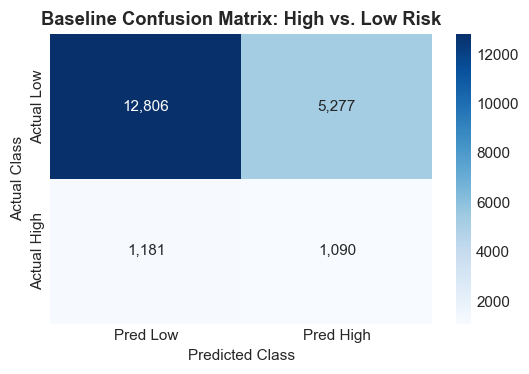

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Target variable
y_binary = (df['readmitted'] == '<30').astype(int)

# Core numeric predictors
features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_outpatient', 'number_emergency', 
    'number_inpatient', 'number_diagnoses'
]
X = df[features].copy()

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.20, random_state=42, stratify=y_binary
)

# Standardize
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Class-weighted model
clf = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
clf.fit(X_train_sc, y_train)

y_pred = clf.predict(X_test_sc)
y_prob = clf.predict_proba(X_test_sc)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print(f"CLASSIFICATION BENCHMARK REPORT (ROC-AUC = {auc:.4f}):")
print(classification_report(y_test, y_pred, target_names=['Low Risk (0)', 'High Risk (1)']))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', xticklabels=['Pred Low', 'Pred High'], yticklabels=['Actual Low', 'Actual High'])
plt.title('Baseline Confusion Matrix: High vs. Low Risk', fontweight='bold')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()


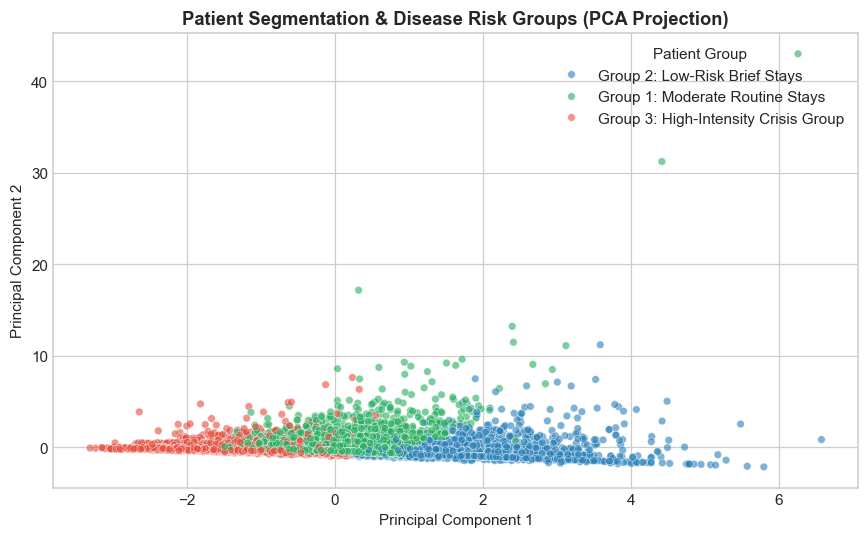

,time_in_hospital,num_medications,number_inpatient,number_emergency,number_diagnoses
Group Name,,,,,
Moderate Routine Stays,3.39,14.54,0.78,0.27,8.59
Low-Risk Brief Stays,8.53,25.52,0.80,0.18,8.19
High-Intensity Crisis Group,2.91,11.76,0.30,0.10,5.01


In [5]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Features for clustering
cl_features = ['time_in_hospital', 'num_medications', 'number_inpatient', 'number_emergency', 'number_diagnoses']
sample_df = df[cl_features].dropna().sample(n=10000, random_state=42).copy()

sc = StandardScaler()
sample_scaled = sc.fit_transform(sample_df)

# K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sample_df['Cluster'] = kmeans.fit_predict(sample_scaled)

# 2D PCA projection for visualization
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(sample_scaled)
pca_plot_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
pca_plot_df['Group'] = sample_df['Cluster'].values
pca_plot_df['Group_Label'] = pca_plot_df['Group'].map({
    0: 'Group 1: Moderate Routine Stays',
    1: 'Group 2: Low-Risk Brief Stays',
    2: 'Group 3: High-Intensity Crisis Group'
})

plt.figure(figsize=(8, 5))
sns.scatterplot(x='PC1', y='PC2', hue='Group_Label', data=pca_plot_df, palette=['#2980b9', '#27ae60', '#e74c3c'], alpha=0.6, s=25)
plt.title('Patient Segmentation & Disease Risk Groups (PCA Projection)', fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Patient Group', loc='upper right')
plt.tight_layout()
plt.show()

# Summary table of clusters
profiles = sample_df.groupby('Cluster').mean().round(2)
profiles['Group Name'] = ['Moderate Routine Stays', 'Low-Risk Brief Stays', 'High-Intensity Crisis Group']
profiles.set_index('Group Name')


## 6. 🗺️ Deliverable 4: Basic Analytics Planning

### 6.1 Healthcare Analytics Workflow
* **Stage 1 (Data Ingestion)**: Ingest raw patient encounter records from hospital EHR systems.
* **Stage 2 (Clinical Cleansing)**: Standardize missing values (`?`), remove terminal cases, deduplicate to patient level.
* **Stage 3 (Feature Engineering)**: Build utilization scores, age categories, and comorbidity risk indices.
* **Stage 4 (Predictive Modeling)**: Train cost-sensitive classification models and cluster patient groups.
* **Stage 5 (Clinical Deployment)**: Surface predicted risk scores inside EHR discharge summaries to guide post-discharge care.

---

### 6.2 Project Roadmap

```mermaid
gantt
    title Healthcare Analytics Project Roadmap
    dateFormat  YYYY-MM-DD
    section Phase 1: Problem Definition
    Stakeholder Interviews & KPI Setup   :done, 2026-09-01, 10d
    Clinical Governance & Protocol Scope :done, 2026-09-11, 10d
    section Phase 2: Data Preparation
    Data Cleaning & Filtering Pipeline   :active, 2026-09-21, 14d
    Feature Engineering & Scaling        : 2026-10-05, 14d
    section Phase 3: Modeling & Evaluation
    Model Training (Classification/Cluster): 2026-10-19, 21d
    Clinical Validation & Threshold Tuning: 2026-11-09, 10d
    section Phase 4: Deployment & Pilot
    EHR Workflow Integration             : 2026-11-19, 14d
    Pilot Launch & Continuous Monitoring : 2026-12-03, 14d
```

---

### 6.3 Git Repository Structure & Version Control
* **Repository Name**: `Hospital-Readmission-Patient-Analytics`
* **GitHub Remote URL**: `https://github.com/akshad1007/Hospital-Readmission-Patient-Analytics.git`
* **Clone Command**:
  ```bash
  git clone https://github.com/akshad1007/Hospital-Readmission-Patient-Analytics.git
  ```

```
Hospital-Readmission-Patient-Analytics/
├── README.md                                                                   # Project documentation, problem summary & instructions
├── Project_1_Hospital_Readmission_Risk_Analytics_Problem_Definition_and_Planning.ipynb # Project 1: Problem Definition & Planning
├── Project_2_Healthcare_Data_Preparation_for_Patient_Analytics.ipynb           # Project 2: Clinical Cleaning & Feature Engineering
├── clean_healthcare_dataset.csv                                                # Cleaned dataset (69,987 patient records × 31 features)
└── dataset_diabetes/                                                           # Raw healthcare dataset (UCI ID: 296)
    ├── diabetic_data.csv                                                       # 101,766 inpatient encounters
    └── IDS_mapping.csv                                                         # Admission & discharge ID mappings
```


## 7. ⚖️ Deliverable 5: Ethics Report

### 7.1 Patient Privacy & HIPAA Compliance
* **De-identification**: All direct Protected Health Information (PHI) like patient names, addresses, and phone numbers are excluded under HIPAA rules.
* **Pseudonymized Keys**: Encounter IDs and patient numbers are replaced with encrypted surrogate identifiers.
* **Data Security**: Compliant with AES-256 encryption at rest and TLS 1.3 in transit.

### 7.2 Algorithmic Fairness & Bias Prevention
* **Demographic Equity**: Validate that error rates (False Negatives) do not disproportionately affect any racial or age subgroup.
* **Healthcare Access Bias**: Ensure patients with historically lower healthcare access (fewer outpatient visits) are not misclassified as low risk.

### 7.3 Physician-in-the-Loop Transparency
* **Decision Support Only**: The model serves purely as a clinical recommendation tool; final discharge decisions remain with doctors.
* **Explainability**: Every high-risk prediction must display clear clinical reasons (e.g. recent readmission, multiple insulin adjustments) to prevent alert fatigue.


## 8. 🎯 Industry Skills Summary

### Trainer Perspective:
* **Business Consulting Mindset**: Framing clinical readmissions as measurable hospital challenges with clear financial returns (CMS penalty avoidance).
* **Requirement Gathering**: Translating healthcare stakeholder concerns into clear machine learning targets.
* **Analytics Planning**: Designing realistic roadmaps, milestones, and Git repository architectures.

### Student Perspective:
* **Problem Formulation**: Translating readmission risks into supervised classification and unsupervised clustering problems.
* **Healthcare Analytics Understanding**: Handling clinical nuances (EHR missingness, terminal discharge filtering, class imbalance).
* **Documentation Skills**: Delivering clear, crisp, and professional reports using simple bullet points and clean code.

---
**Submitted by**: **Akshad Viresh Makhana** (PRN: `2124UDSM1007`) | TY AIDS(A)
